In [20]:
import pandas as pd
import numpy as np

countries = ["ethiopia", "sudan", "tanzania", "nigeria", "kenya"]

dfs = []

for c in countries:
    df = pd.read_csv(f"../data/{c}_clean.csv")
    
    # ensure RAIN_FLAG exists in ALL datasets
    if "RAIN_FLAG" not in df.columns:
        df["RAIN_FLAG"] = (df["PRECTOTCORR"] > 0).astype(int)
    
    df["Country"] = c.capitalize()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,RAIN_FLAG
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,0
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,0
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,0
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,0
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,0


In [21]:
# check all country exists
data["Country"].value_counts()

Country
Ethiopia    4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Kenya       4108
Name: count, dtype: int64

In [22]:
# sample from each country
data.sample(10)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,RAIN_FLAG
16755,2015,324,20.9400,28.32,16.02,12.30,1.920000,73.94,3.52,4.26,83.53,13.02,Kenya,2015-11-20,11,1
9702,2019,26,28.7100,31.67,26.53,5.14,0.947789,71.29,3.87,4.66,100.67,17.41,Tanzania,2019-01-26,1,1
16409,2026,68,28.8086,31.74,26.82,5.41,0.815365,78.11,3.03,3.42,100.58,19.60,Nigeria,2026-03-09,3,1
17403,2017,241,20.2100,27.40,14.39,13.01,0.320000,61.61,2.44,4.23,83.64,10.31,Kenya,2017-08-29,8,1
1103,2018,8,15.2800,21.98,9.64,12.34,0.000000,64.74,1.94,2.80,77.03,8.69,Ethiopia,2018-01-08,1,0
12260,2026,27,27.9600,30.67,26.03,4.64,0.652325,74.03,4.54,5.21,100.62,17.36,Tanzania,2026-01-27,1,1
14631,2021,116,27.9200,29.77,26.27,3.50,0.631272,85.30,2.16,2.53,100.59,20.06,Nigeria,2021-04-26,4,1
19668,2023,315,19.8500,25.71,15.80,9.91,7.690000,81.76,4.29,5.08,83.71,13.89,Kenya,2023-11-11,11,1
2708,2022,152,19.9700,27.62,13.34,14.28,0.130000,47.90,2.55,4.80,76.90,8.42,Ethiopia,2022-06-01,6,1
15319,2023,74,27.7200,30.09,26.16,3.93,0.974560,82.57,2.34,3.09,100.52,19.14,Nigeria,2023-03-15,3,1


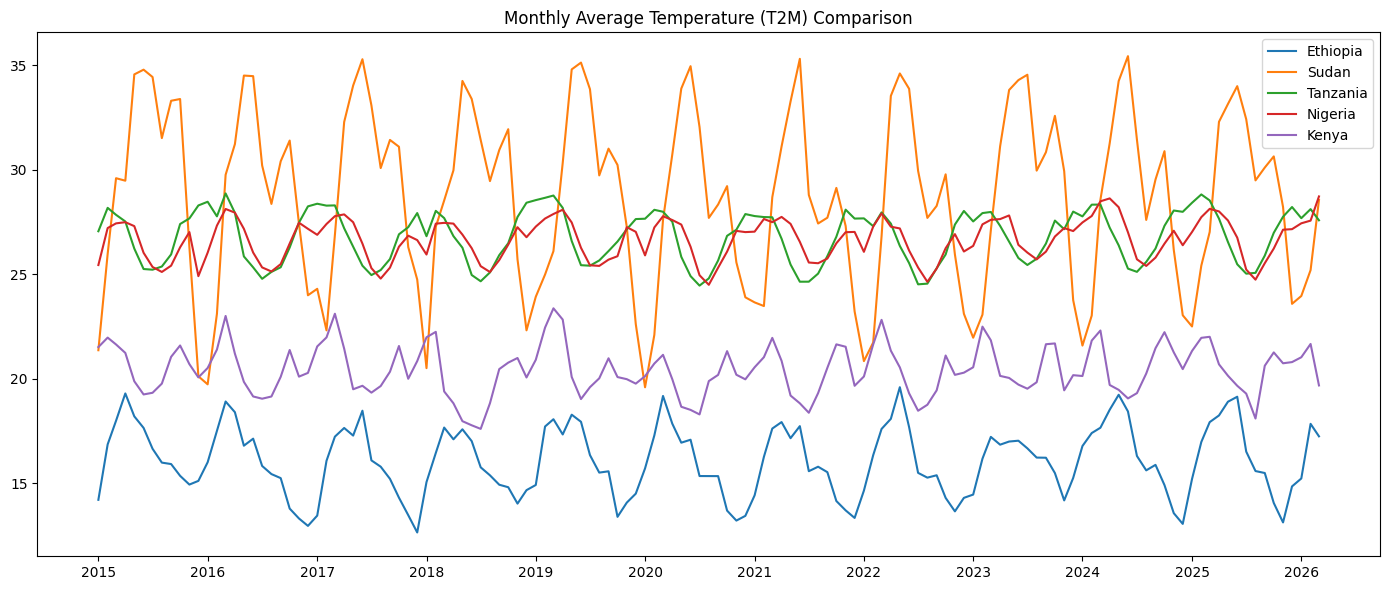

In [23]:
data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.to_period("M")

monthly_temp = data.groupby(["Month", "Country"])["T2M"].mean().reset_index()
monthly_temp["Month"] = monthly_temp["Month"].astype(str)

import matplotlib.pyplot as plt

import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

for c in countries:
    temp = monthly_temp[monthly_temp["Country"] == c.capitalize()]
    plt.plot(pd.to_datetime(temp["Month"]), temp["T2M"], label=c.capitalize())

plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # yearly ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Monthly Average Temperature (T2M) Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
temp_summary = data.groupby("Country")["T2M"].agg([
    "mean", "median", "std"
]).reset_index()

temp_summary

,Country,mean,median,std
0,Ethiopia,16.068679,16.04,1.897501
1,Kenya,20.427245,20.36,1.419770
2,Nigeria,26.661339,26.82,1.099749
3,Sudan,28.764489,29.16,4.646585
4,Tanzania,26.803544,26.99,1.314036


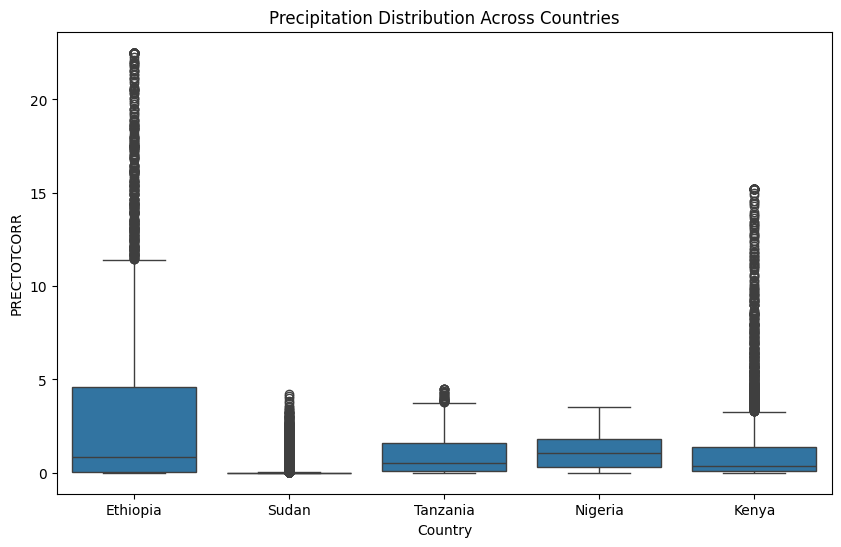

In [25]:
# Perception
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=data)
plt.title("Precipitation Distribution Across Countries")
plt.show()

In [26]:
#perception sumamry
rain_summary = data.groupby("Country")["PRECTOTCORR"].agg([
    "mean", "median", "std"
]).reset_index()

rain_summary

,Country,mean,median,std
0,Ethiopia,3.440719,0.820000,5.374903
1,Kenya,1.387496,0.380000,2.583726
2,Nigeria,1.146307,1.043804,0.931768
3,Sudan,0.193805,0.000000,0.541678
4,Tanzania,0.920065,0.494696,0.988982


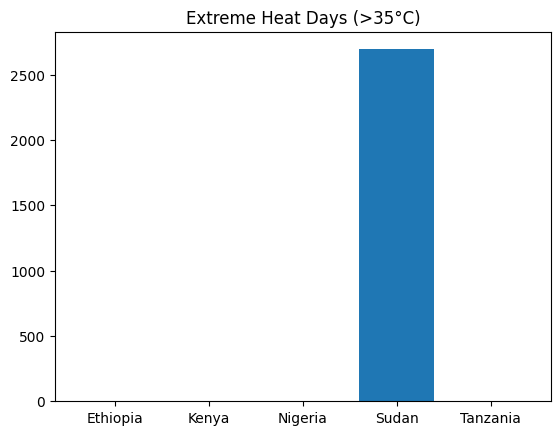

In [27]:
# Extream heat plot
plt.bar(heat_events["Country"], heat_events["Extreme_Heat_Days"])
plt.title("Extreme Heat Days (>35°C)")
plt.show()

In [28]:
# Extream heat table
data["Extreme_Heat"] = data["T2M_MAX"] > 35

heat_events = data.groupby("Country")["Extreme_Heat"].sum().reset_index()
heat_events.columns = ["Country", "Extreme_Heat_Days"]

heat_events

,Country,Extreme_Heat_Days
0,Ethiopia,0
1,Kenya,0
2,Nigeria,0
3,Sudan,2694
4,Tanzania,0


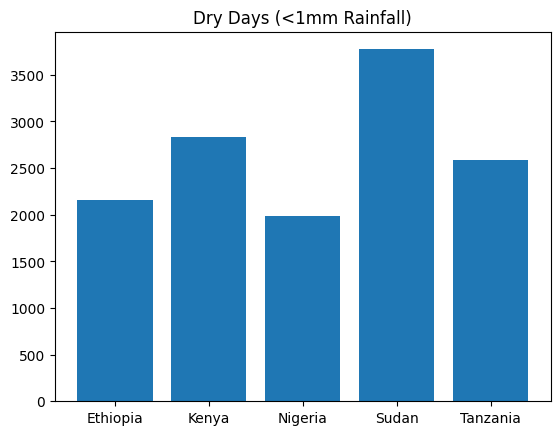

In [29]:
# Dry plot 
plt.bar(dry_days["Country"], dry_days["Dry_Days"])
plt.title("Dry Days (<1mm Rainfall)")
plt.show()

In [16]:
# Dry table
data["Dry_Day"] = data["PRECTOTCORR"] < 1

dry_days = data.groupby("Country")["Dry_Day"].sum().reset_index()
dry_days.columns = ["Country", "Dry_Days"]

dry_days

,Country,Dry_Days
0,Ethiopia,2161
1,Kenya,2831
2,Nigeria,1990
3,Sudan,3774
4,Tanzania,2592


In [18]:
# Tempreatre significnt test
from scipy.stats import f_oneway

groups = [data[data["Country"] == c.capitalize()]["T2M"] for c in countries]

f_stat, p_value = f_oneway(*groups)

print("ANOVA F-stat:", f_stat)
print("p-value:", p_value)

ANOVA F-stat: 19248.00196832356
p-value: 0.0


In [19]:
# Vulnabrity
ranking = temp_summary.copy()
ranking = ranking.rename(columns={"mean":"Temp_Mean", "std":"Temp_Std"})
ranking = ranking.merge(rain_summary, on="Country")
ranking = ranking.merge(heat_events, on="Country")
ranking = ranking.merge(dry_days, on="Country")

ranking

,Country,Temp_Mean,median_x,Temp_Std,mean,median_y,std,Extreme_Heat_Days,Dry_Days
0,Ethiopia,16.068679,16.04,1.897501,3.440719,0.820000,5.374903,0,2161
1,Kenya,20.427245,20.36,1.419770,1.387496,0.380000,2.583726,0,2831
2,Nigeria,26.661339,26.82,1.099749,1.146307,1.043804,0.931768,0,1990
3,Sudan,28.764489,29.16,4.646585,0.193506,0.000000,0.539616,2694,3774
4,Tanzania,26.803544,26.99,1.314036,0.920065,0.494696,0.988982,0,2592
